# Exploratory Data Analysis (EDA)

## 3.1 Introduction

### Objective

The objective of Exploratory Data Analysis is to examine the major patterns and relationships within the UAC care pipeline. The analysis focuses on changes over time, differences between CBP and HHS activity, operational pressure, reporting patterns, and the distribution of the major care-stage variables.

The findings from this phase will guide the development of formal efficiency and bottleneck indicators in the subsequent analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 3.2 Dataset Overview

### Description

The cleaned dataset represents multiple stages of the UAC care process, including apprehension, CBP custody, transfer to HHS care, HHS care population, and discharge from HHS care.

The variables are analyzed according to whether they represent population snapshots or activity occurring during the reporting period.

In [3]:
df = pd.read_csv("../data/processed/uac_cleaned.csv")

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)

display(df.head())

Shape: (720, 6)


,date,apprehended,cbp_custody,transferred,hhs_care,discharged
0,2023-01-12,33.00,53.00,34.00,6566,436.00
1,2023-01-22,32.00,49.00,39.00,7122,227.00
2,2023-01-23,32.00,50.00,39.00,7280,181.00
3,2023-01-24,47.00,42.00,47.00,7433,175.00
4,2023-01-25,20.00,22.00,41.00,7538,180.00


In [4]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
date,720,2024-07-06 05:30:00,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN
apprehended,720.00,93.52,0.00,12.00,99.00,147.25,333.00,72.65
cbp_custody,720.00,171.49,7.00,36.00,193.00,263.25,531.00,126.35
transferred,720.00,128.67,0.00,14.00,157.00,199.25,440.00,97.32
hhs_care,720.00,6061.27,1972.00,2467.75,6406.50,8010.25,11516.00,2833.07
discharged,720.00,173.41,0.00,19.75,181.00,267.00,505.00,125.70


In [5]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of observations:", len(df))

Start date: 2023-01-12 00:00:00
End date: 2025-12-21 00:00:00
Number of observations: 720


In [6]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of observations:", len(df))

Start date: 2023-01-12 00:00:00
End date: 2025-12-21 00:00:00
Number of observations: 720


In [7]:
pipeline_columns = [
    "apprehended",
    "cbp_custody",
    "transferred",
    "hhs_care",
    "discharged"
]

pipeline_summary = pd.DataFrame({
    "Mean": df[pipeline_columns].mean(),
    "Median": df[pipeline_columns].median(),
    "Minimum": df[pipeline_columns].min(),
    "Maximum": df[pipeline_columns].max()
})

display(pipeline_summary)

,Mean,Median,Minimum,Maximum
apprehended,93.52,99.00,0.00,333.00
cbp_custody,171.49,193.00,7.00,531.00
transferred,128.67,157.00,0.00,440.00
hhs_care,6061.27,6406.50,1972.00,11516.00
discharged,173.41,181.00,0.00,505.00


# 1. Care Pipeline Overview

### Business Question

How does the observed UAC population and activity vary across the different stages of the care pipeline?

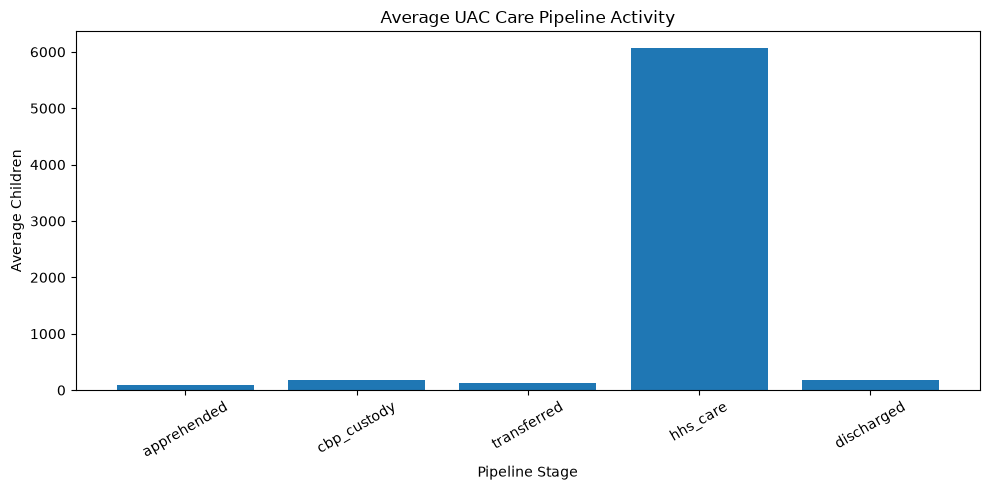

In [8]:
pipeline_means = df[pipeline_columns].mean()

plt.figure(figsize=(10, 5))

plt.bar(
    pipeline_means.index,
    pipeline_means.values
)

plt.title("Average UAC Care Pipeline Activity")
plt.xlabel("Pipeline Stage")
plt.ylabel("Average Children")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Figure 1: Average Activity Across UAC Care Stages

### Key Finding

The UAC care stages operate at different scales, with HHS care representing a substantially larger population than the CBP custody measures. This difference should be considered when comparing stages directly.

### Business Implication

The different scales of the care stages indicate that CBP and HHS activity should be evaluated separately as well as within the overall care pipeline.

# 2. Trends in UAC Care Activity

### Business Question

How have apprehensions, CBP custody, transfers, HHS care, and discharges changed over the observation period?

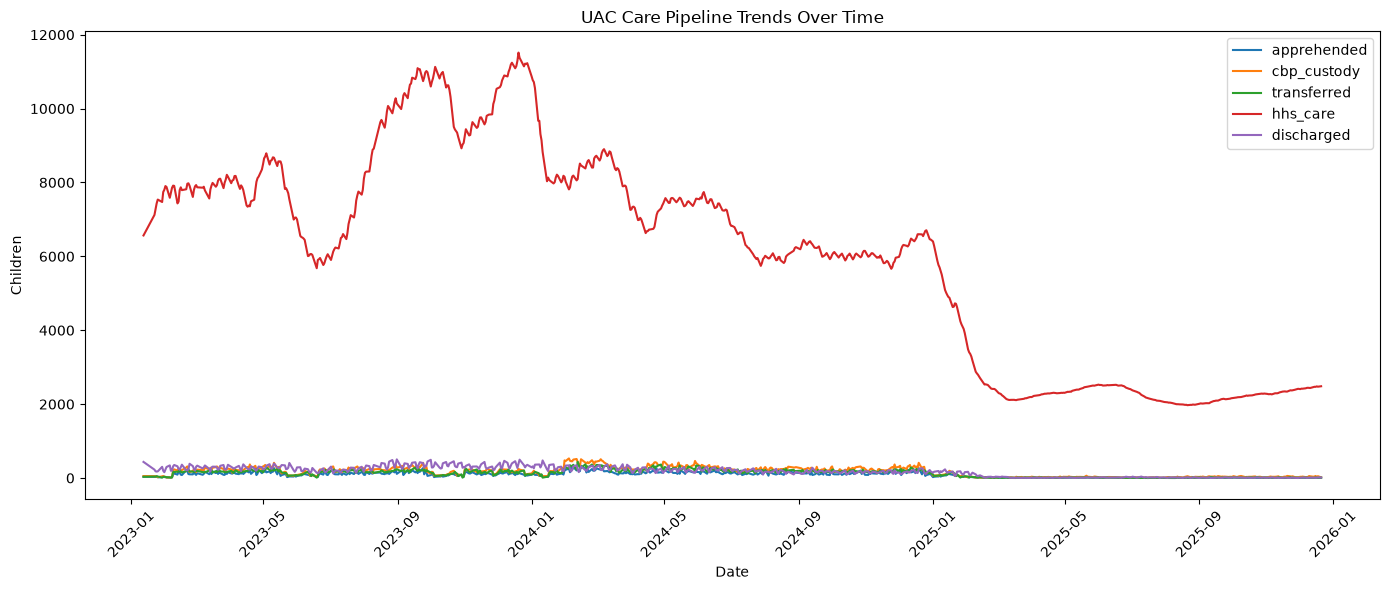

In [9]:
plt.figure(figsize=(14, 6))

for column in pipeline_columns:
    plt.plot(
        df["date"],
        df[column],
        label=column
    )

plt.title("UAC Care Pipeline Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 2: UAC Care Activity Over Time

### Key Finding

The time-series analysis identifies periods of increased and decreased activity across the different stages of the UAC care pipeline. These changes provide an initial indication of periods requiring closer operational analysis.

### Business Implication

Periods of sustained increases in inflows or decreases in exits may place additional pressure on downstream stages of the care process and should be examined further in the bottleneck analysis.

# 3. CBP Custody and Transfer Activity

### Business Question

How do apprehensions, CBP custody, and transfers vary over time, and are there periods where incoming activity exceeds transfers?

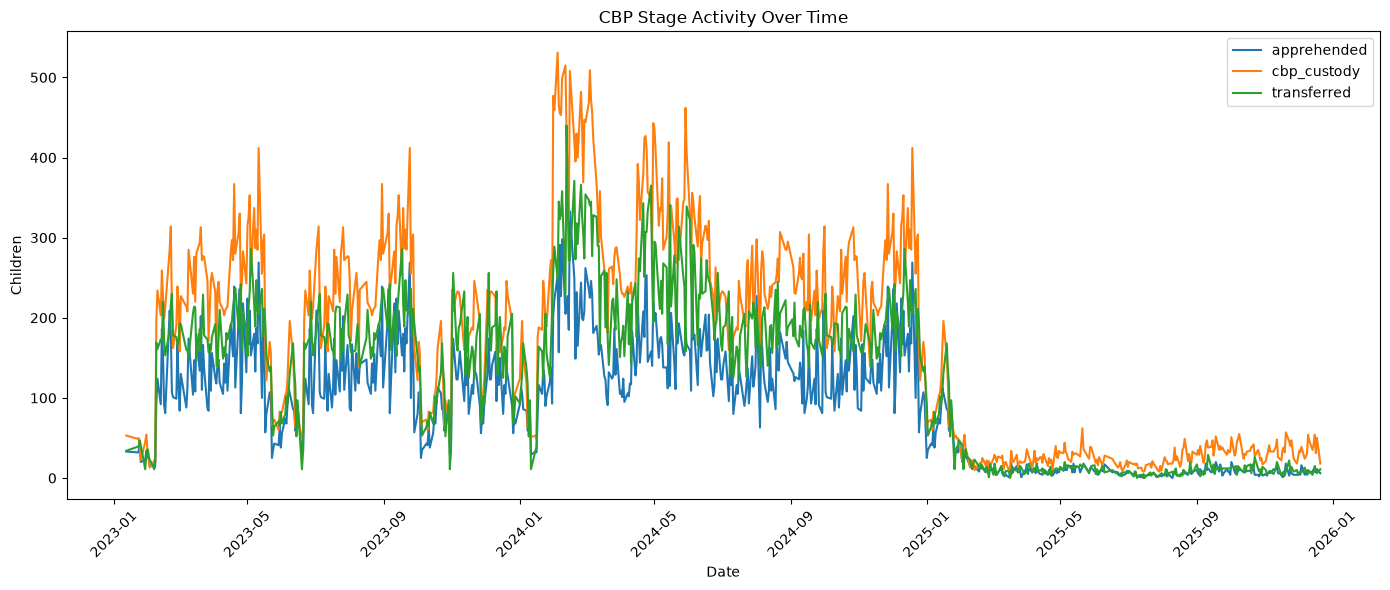

In [10]:
cbp_columns = [
    "apprehended",
    "cbp_custody",
    "transferred"
]

plt.figure(figsize=(14, 6))

for column in cbp_columns:
    plt.plot(
        df["date"],
        df[column],
        label=column
    )

plt.title("CBP Stage Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 3: CBP Apprehensions, Custody, and Transfers

### Key Finding

The comparison between apprehensions and transfers highlights periods where incoming activity may place greater operational pressure on the CBP stage.

### Business Implication

Periods of higher net CBP pressure can be used to identify dates requiring further investigation in the care transition analysis.

# 4. HHS Care and Discharge Activity

### Business Question

How does HHS care activity compare with discharge activity over time?

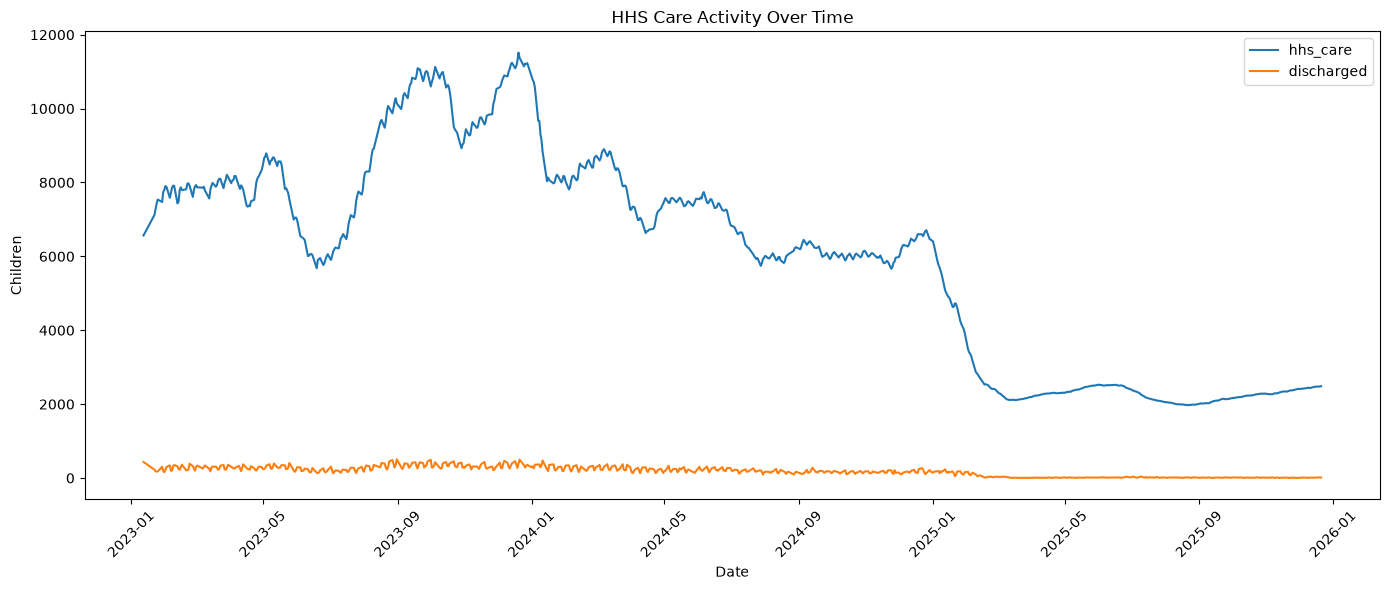

In [11]:
hhs_columns = [
    "hhs_care",
    "discharged"
]

plt.figure(figsize=(14, 6))

for column in hhs_columns:
    plt.plot(
        df["date"],
        df[column],
        label=column
    )

plt.title("HHS Care Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 4: HHS Care Population and Discharges Over Time

### Key Finding

The relationship between HHS care and discharge activity provides an initial view of the balance between the population in HHS care and exits from the stage.

### Business Implication

Periods where transfers into HHS care are not matched by corresponding discharge activity may indicate increased operational pressure and should be examined in the next phase.

# 5. Monthly UAC Activity Trends

### Business Question

Do the major UAC care-stage measures show consistent patterns across months?

In [12]:
df["month"] = df["date"].dt.to_period("M")

monthly = (
    df.groupby("month")[pipeline_columns]
    .mean()
    .reset_index()
)

monthly["month"] = monthly["month"].dt.to_timestamp()

display(monthly.head())

,month,apprehended,cbp_custody,transferred,hhs_care,discharged
0,2023-01-01,30.88,43.88,34.50,7369.62,232.00
1,2023-02-01,99.26,171.32,138.79,7795.79,272.79
2,2023-03-01,130.47,245.11,178.89,7945.37,282.89
3,2023-04-01,149.00,250.19,188.90,7842.67,269.90
4,2023-05-01,124.82,216.95,164.64,8187.14,284.36


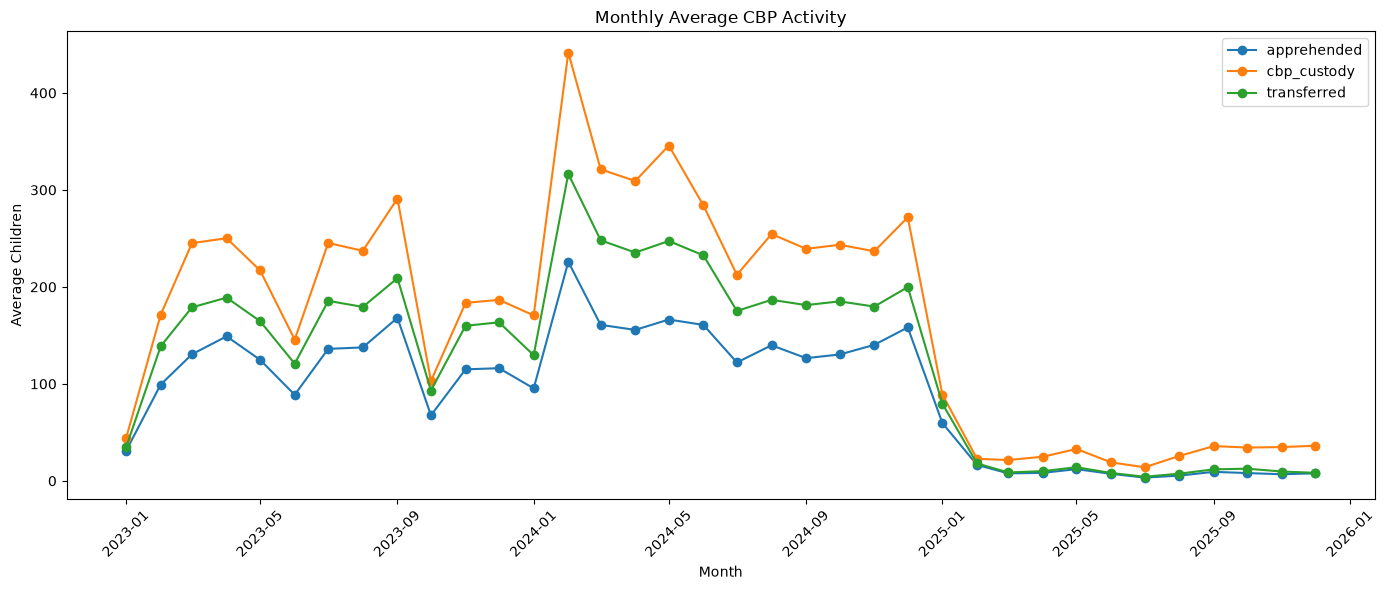

In [13]:
plt.figure(figsize=(14, 6))

for column in cbp_columns:
    plt.plot(
        monthly["month"],
        monthly[column],
        marker="o",
        label=column
    )

plt.title("Monthly Average CBP Activity")
plt.xlabel("Month")
plt.ylabel("Average Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 5.1: Monthly CBP Activity

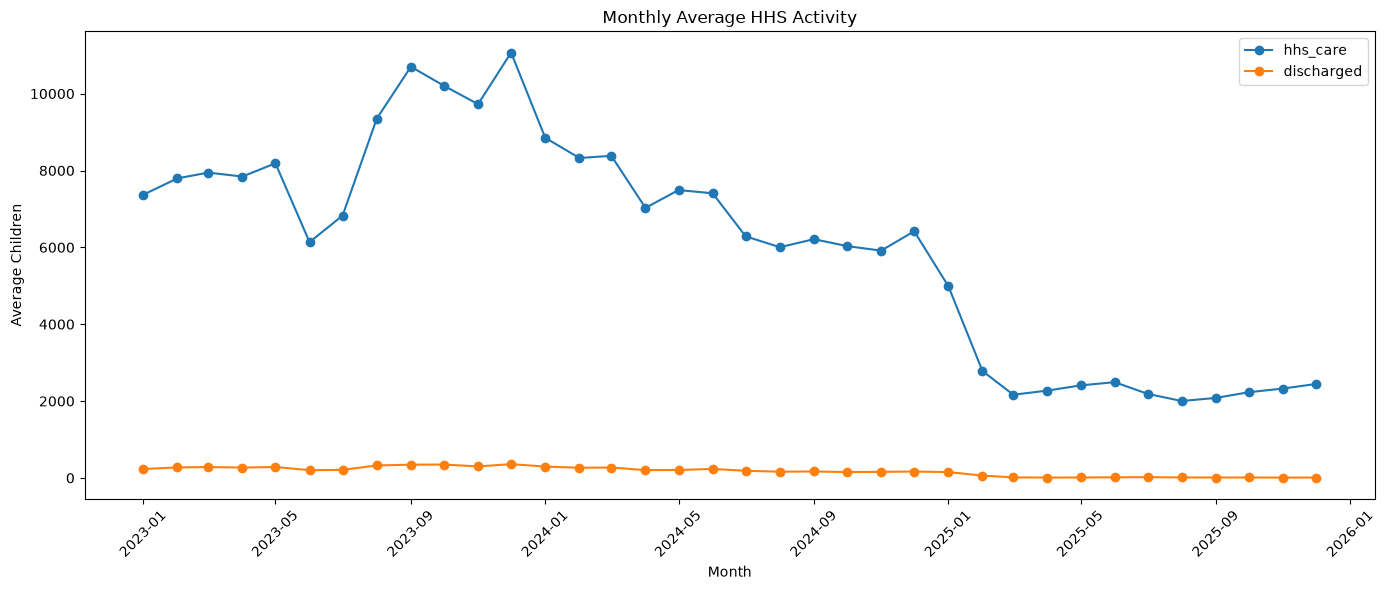

In [14]:
plt.figure(figsize=(14, 6))

for column in hhs_columns:
    plt.plot(
        monthly["month"],
        monthly[column],
        marker="o",
        label=column
    )

plt.title("Monthly Average HHS Activity")
plt.xlabel("Month")
plt.ylabel("Average Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 5.2: Monthly HHS Activity

### Key Finding

Monthly aggregation reduces short-term fluctuations and provides a clearer view of broader changes in UAC activity across the observation period.

### Business Implication

Monthly patterns can help identify periods of sustained operational pressure that may not be apparent from individual daily observations.

# 6. Year-over-Year Activity

### Business Question

How has the overall level of UAC activity changed between years?

In [15]:
df["year"] = df["date"].dt.year

yearly = (
    df.groupby("year")[pipeline_columns]
    .mean()
)

display(yearly)

,apprehended,cbp_custody,transferred,hhs_care,discharged
year,,,,,
2023,117.63,200.47,157.06,8646.07,288.02
2024,148.07,276.90,209.37,7042.96,205.93
2025,13.03,32.91,16.59,2542.84,28.95


In [16]:
yearly_change = yearly.pct_change() * 100

display(
    yearly_change.round(2)
)

,apprehended,cbp_custody,transferred,hhs_care,discharged
year,,,,,
2023,NaN,NaN,NaN,NaN,NaN
2024,25.87,38.13,33.31,-18.54,-28.50
2025,-91.20,-88.12,-92.08,-63.90,-85.94


<Figure size 1200x600 with 0 Axes>

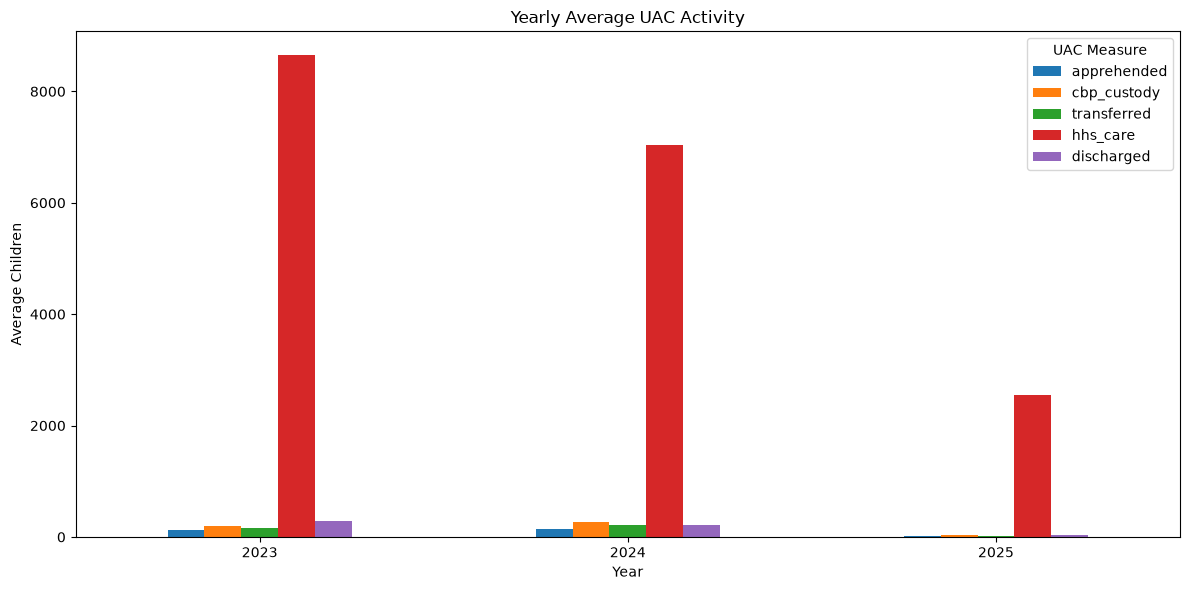

In [17]:
plt.figure(figsize=(12, 6))

yearly.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Yearly Average UAC Activity")
plt.xlabel("Year")
plt.ylabel("Average Children")
plt.xticks(rotation=0)
plt.legend(title="UAC Measure")
plt.tight_layout()
plt.show()

### Figure 6: Yearly Average UAC Activity

### Key Finding

Year-level comparisons provide a high-level view of changes in the scale of activity across the UAC care pipeline.

### Business Implication

Significant changes between years can help identify periods that require more detailed temporal and operational investigation.

# 7. CBP Operational Pressure

### Business Question

Are there periods where apprehensions exceed transfers out of CBP custody?

In [18]:
df["cbp_net_pressure"] = (
    df["apprehended"] - df["transferred"]
)

display(
    df[
        ["date", "apprehended", "transferred", "cbp_net_pressure"]
    ].head(10)
)

,date,apprehended,transferred,cbp_net_pressure
0,2023-01-12,33.00,34.00,-1.00
1,2023-01-22,32.00,39.00,-7.00
2,2023-01-23,32.00,39.00,-7.00
3,2023-01-24,47.00,47.00,0.00
4,2023-01-25,20.00,41.00,-21.00
5,2023-01-29,23.00,11.00,12.00
6,2023-01-30,34.00,29.00,5.00
7,2023-01-31,26.00,36.00,-10.00
8,2023-02-01,25.00,27.00,-2.00
9,2023-02-02,15.00,23.00,-8.00


In [19]:
df["hhs_net_pressure"] = (
    df["transferred"] - df["discharged"]
)

display(
    df[
        ["date", "transferred", "discharged", "hhs_net_pressure"]
    ].head(10)
)

,date,transferred,discharged,hhs_net_pressure
0,2023-01-12,34.00,436.00,-402.00
1,2023-01-22,39.00,227.00,-188.00
2,2023-01-23,39.00,181.00,-142.00
3,2023-01-24,47.00,175.00,-128.00
4,2023-01-25,41.00,180.00,-139.00
5,2023-01-29,11.00,303.00,-292.00
6,2023-01-30,29.00,196.00,-167.00
7,2023-01-31,36.00,158.00,-122.00
8,2023-02-01,27.00,231.00,-204.00
9,2023-02-02,23.00,298.00,-275.00


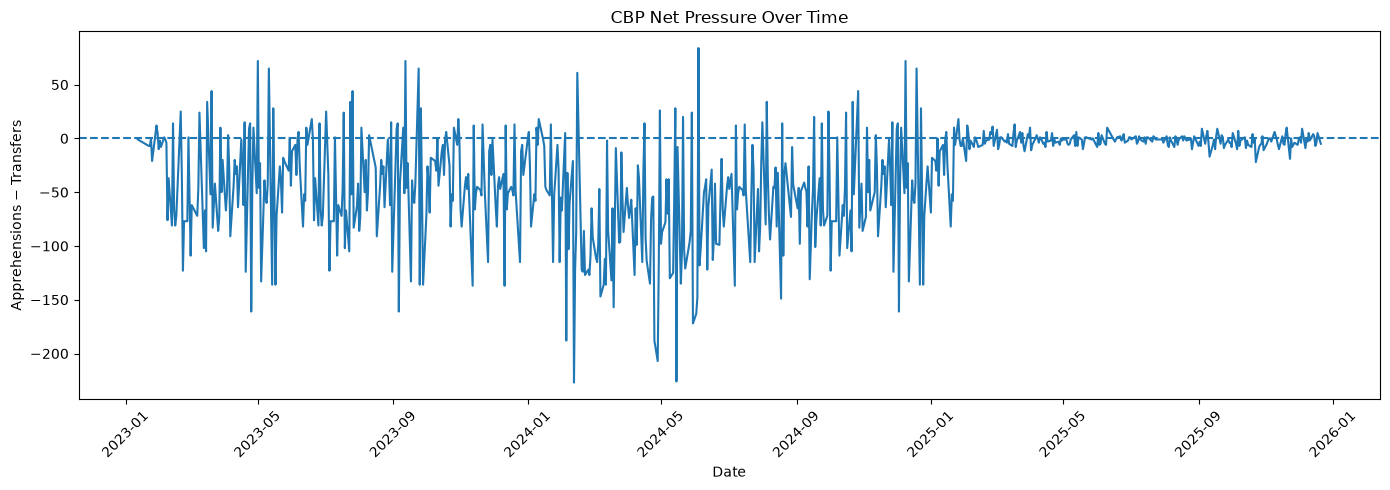

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["cbp_net_pressure"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("CBP Net Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Apprehensions − Transfers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 7: CBP Net Pressure Over Time

### Key Finding

CBP Net Pressure identifies reporting periods where apprehension activity exceeds transfers. Positive values indicate greater incoming activity relative to transfers during the observed period.

### Business Implication

Sustained positive CBP pressure may indicate periods where the transition from apprehension to transfer requires closer operational examination.

# 8. HHS Operational Pressure

### Business Question

Are there periods where transfers into HHS care exceed discharges from HHS care?

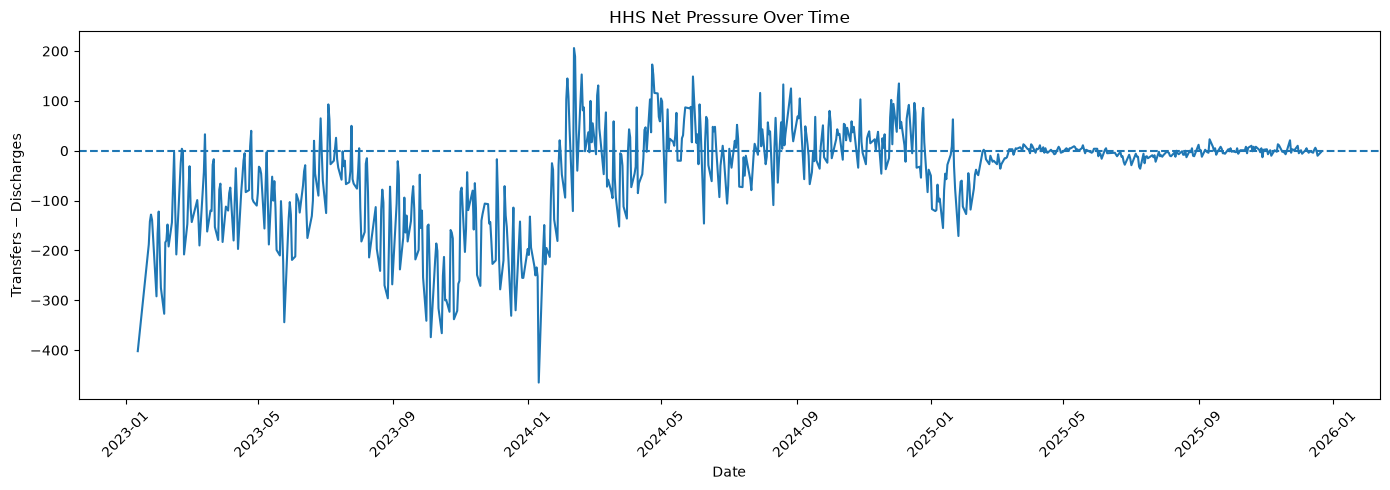

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["hhs_net_pressure"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("HHS Net Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Transfers − Discharges")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 8: HHS Net Pressure Over Time

### Key Finding

HHS Net Pressure highlights periods where transfer activity exceeds discharge activity.

### Business Implication

Periods of sustained positive HHS pressure can be used to identify potential accumulation pressure within the downstream care stage.

# 9. Distribution of UAC Care Measures

### Business Question

How variable are the major UAC care-stage measures across the observation period?

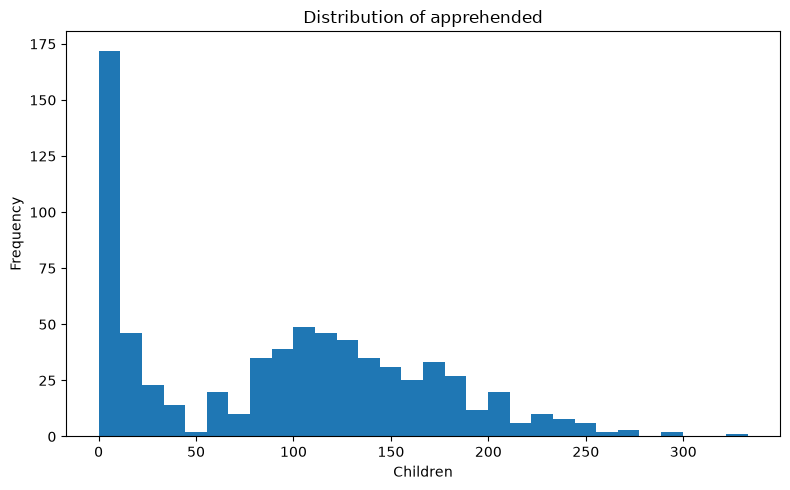

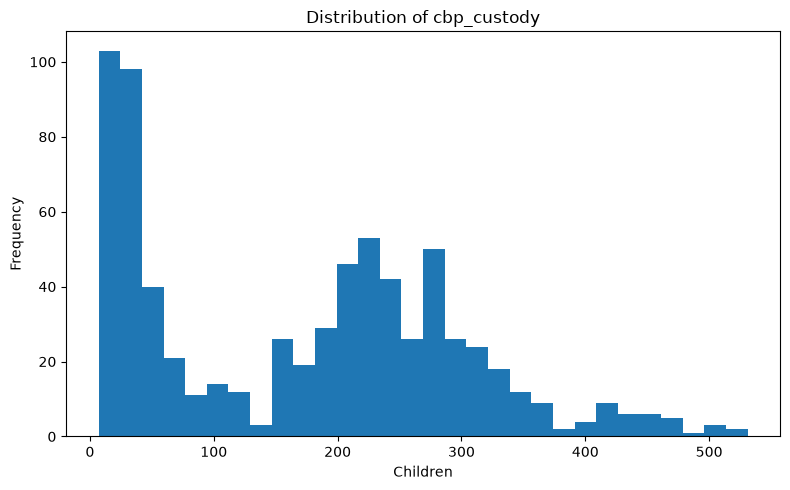

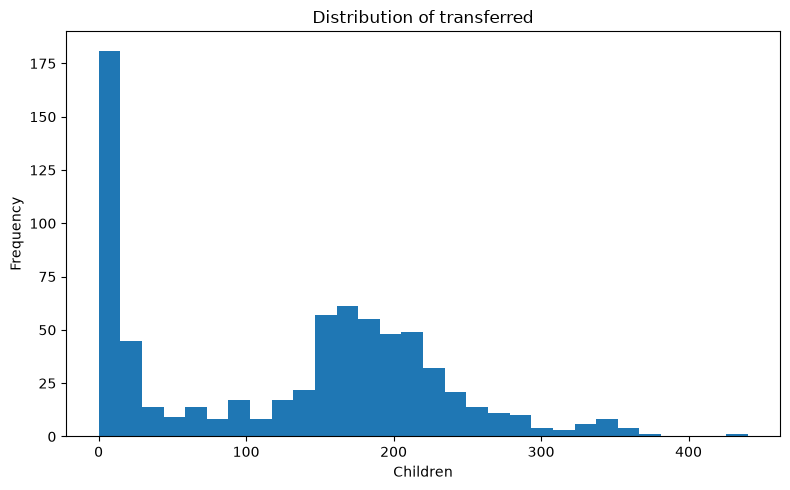

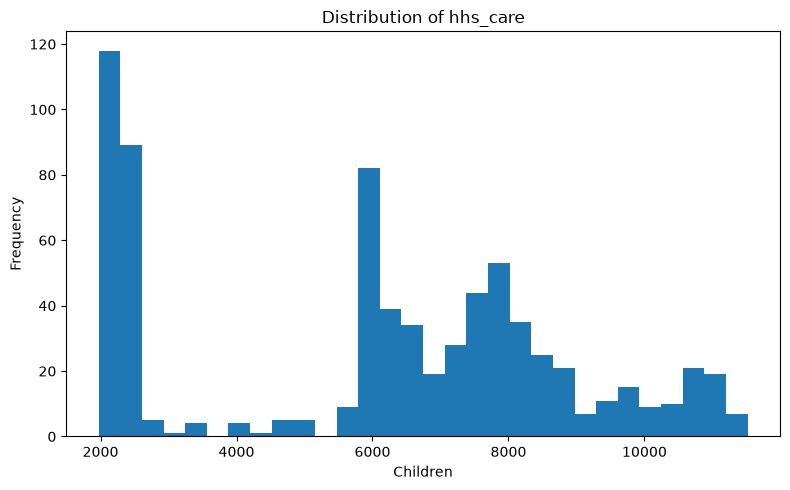

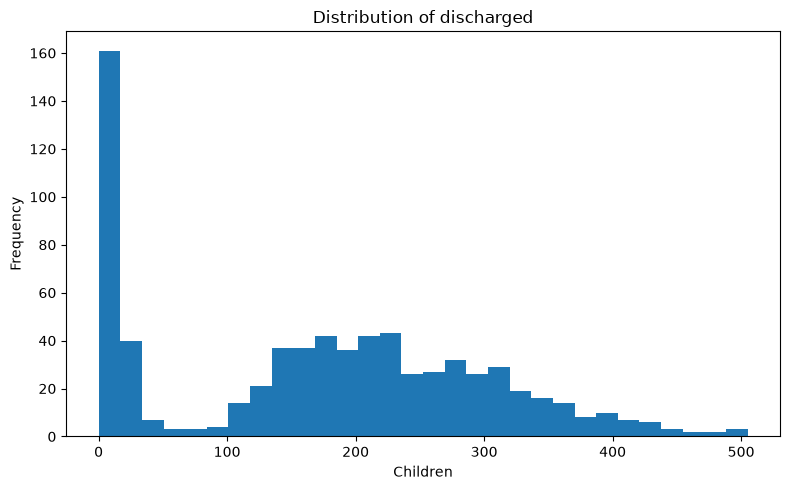

In [22]:
for column in pipeline_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(df[column], bins=30)

    plt.title(f"Distribution of {column}")
    plt.xlabel("Children")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Figure 9.1: Distribution of CBP Activity and HHS Activity

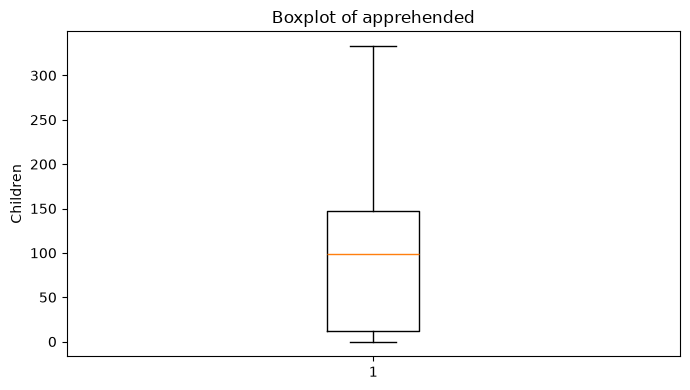

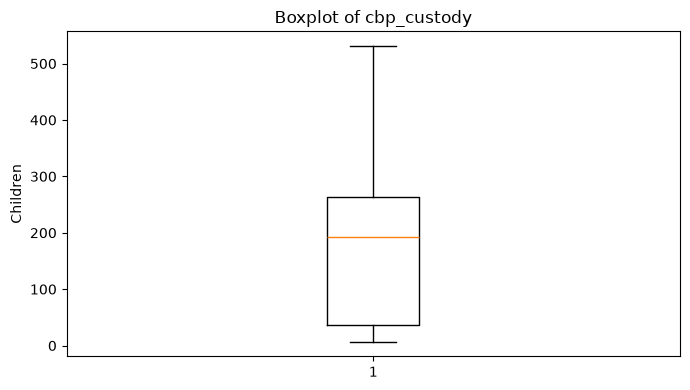

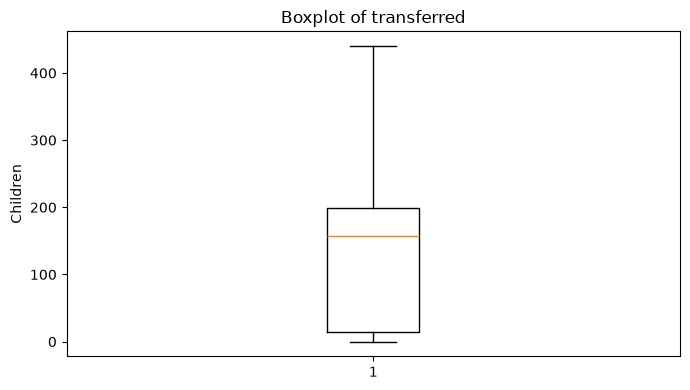

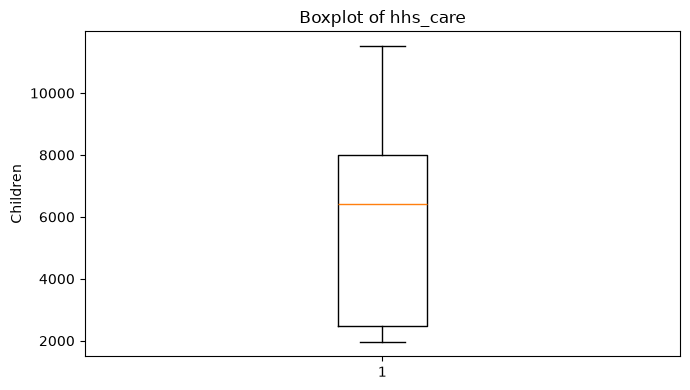

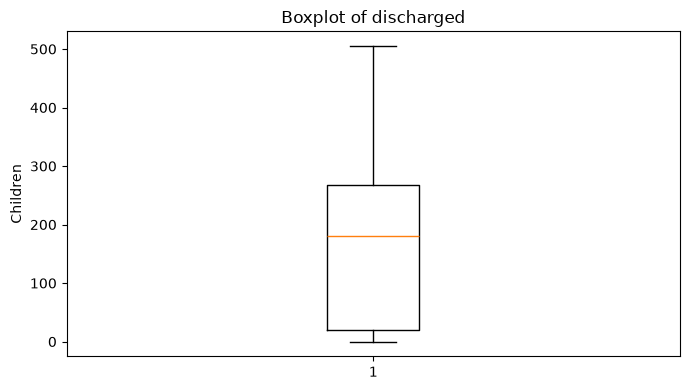

In [23]:
for column in pipeline_columns:

    plt.figure(figsize=(7, 4))

    plt.boxplot(df[column].dropna())

    plt.title(f"Boxplot of {column}")
    plt.ylabel("Children")

    plt.tight_layout()
    plt.show()

### Figure 9.2: Box Plor for Distribution of CBP Activity and HHS Activity

### Key Finding

The distributions show the typical range and variability of activity across the different care stages and help identify unusually high or low observations.

### Business Implication

Understanding the normal range of activity is important when identifying periods of unusually high operational pressure.

# 10. Correlation Analysis

### Business Question

How are the major numerical measures within the UAC care pipeline related to one another?

In [24]:
correlation_matrix = df[pipeline_columns].corr()

display(
    correlation_matrix.round(2)
)

,apprehended,cbp_custody,transferred,hhs_care,discharged
apprehended,1.00,0.95,0.89,0.69,0.63
cbp_custody,0.95,1.00,0.93,0.66,0.60
transferred,0.89,0.93,1.00,0.71,0.66
hhs_care,0.69,0.66,0.71,1.00,0.92
discharged,0.63,0.60,0.66,0.92,1.00


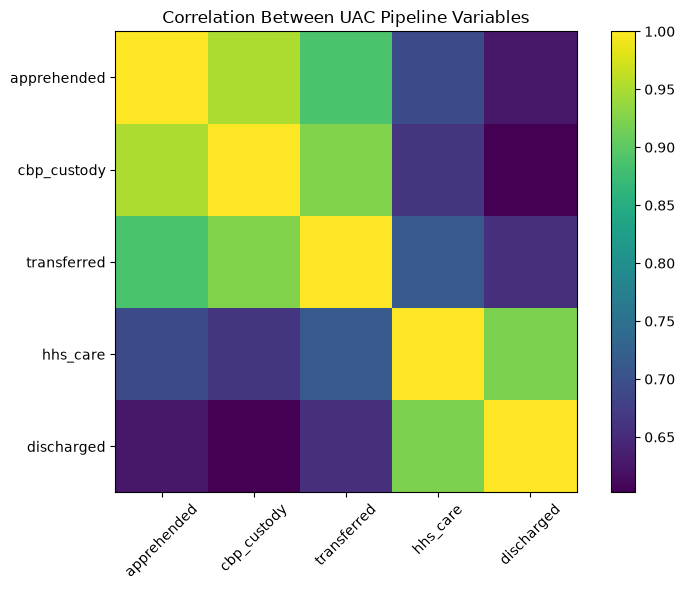

In [25]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(pipeline_columns)),
    pipeline_columns,
    rotation=45
)

plt.yticks(
    range(len(pipeline_columns)),
    pipeline_columns
)

plt.title("Correlation Between UAC Pipeline Variables")

plt.tight_layout()
plt.show()

### Figure 10: Correlation Heatmap of UAC Care Measures

### Business Implication

The correlation analysis provides an overview of the relationships between major UAC care-stage measures and helps identify variables that move together across the reporting period.

Correlation indicates association between variables and should not be interpreted as evidence of a causal relationship.

In [26]:
df["day_of_week"] = df["date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis = (
    df.groupby("day_of_week")[pipeline_columns]
    .mean()
    .reindex(day_order)
)

display(day_analysis)

,apprehended,cbp_custody,transferred,hhs_care,discharged
day_of_week,,,,,
Monday,93.78,167.94,123.73,6063.52,157.56
Tuesday,97.11,173.56,124.86,6082.44,136.11
Wednesday,93.80,175.87,131.67,6158.83,166.01
Thursday,94.69,171.21,133.41,6128.79,205.69
Friday,44.50,111.00,110.00,4296.50,144.00
Saturday,NaN,NaN,NaN,NaN,NaN
Sunday,88.24,169.39,130.06,5875.02,206.14


# 11. Reporting Pattern Analysis

### Business Question

Does UAC activity vary systematically across the observed days of the week?

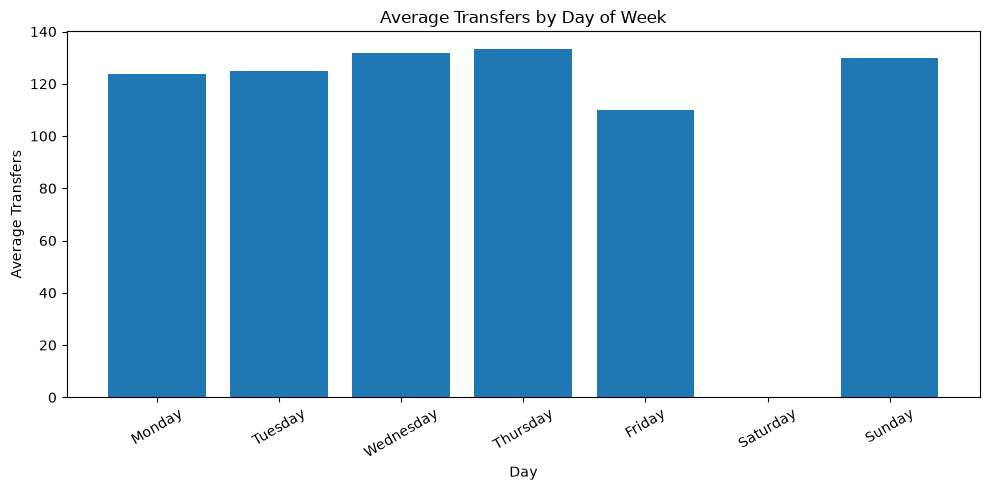

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_analysis.index,
    day_analysis["transferred"]
)

plt.title("Average Transfers by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Transfers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Figure 11: Transfer Activity by Day of Week

### Key Finding

The observed reporting pattern varies across days of the week, reflecting the reporting structure of the dataset as well as potential differences in recorded activity.

### Business Implication

Day-level comparisons should be interpreted alongside the dataset's irregular reporting intervals rather than assuming that an unobserved date represents zero activity.

# 12. High-Pressure Periods

### Business Question

Which reporting periods show the highest CBP and HHS operational pressure?

In [28]:
top_cbp_pressure = (
    df[
        [
            "date",
            "apprehended",
            "transferred",
            "cbp_net_pressure"
        ]
    ]
    .sort_values(
        "cbp_net_pressure",
        ascending=False
    )
    .head(10)
)

display(top_cbp_pressure)

,date,apprehended,transferred,cbp_net_pressure
338,2024-06-04,260.00,176.00,84.00
156,2023-09-12,224.00,152.00,72.00
465,2024-12-09,224.00,152.00,72.00
67,2023-05-01,224.00,152.00,72.00
473,2024-12-19,269.00,204.00,65.00
164,2023-09-24,269.00,204.00,65.00
75,2023-05-11,269.00,204.00,65.00
262,2024-02-15,333.00,272.00,61.00
37,2023-03-20,202.00,158.00,44.00
126,2023-07-26,202.00,158.00,44.00


In [29]:
top_hhs_pressure = (
    df[
        [
            "date",
            "transferred",
            "discharged",
            "hhs_net_pressure"
        ]
    ]
    .sort_values(
        "hhs_net_pressure",
        ascending=False
    )
    .head(10)
)

display(top_hhs_pressure)

,date,transferred,discharged,hhs_net_pressure
259,2024-02-12,440.00,234.00,206.00
260,2024-02-13,349.00,160.00,189.00
309,2024-04-23,307.00,134.00,173.00
310,2024-04-24,307.00,154.00,153.00
263,2024-02-19,371.00,218.00,153.00
335,2024-05-30,339.00,190.00,149.00
255,2024-02-06,323.00,178.00,145.00
461,2024-12-03,242.00,107.00,135.00
391,2024-08-20,245.00,112.00,133.00
274,2024-03-05,345.00,214.00,131.00


### Key Finding

The highest-pressure observations provide a focused set of dates for further investigation in the bottleneck analysis.

### Business Implication

Identifying high-pressure periods allows subsequent analysis to focus on where the care transition system experienced the greatest difference between incoming and outgoing activity.

In [30]:
eda_output = "../data/processed/uac_eda.csv"

df.to_csv(
    eda_output,
    index=False
)

print("EDA dataset saved:")
print(eda_output)

EDA dataset saved:
../data/processed/uac_eda.csv


---

## Executive Summary

The exploratory analysis examined the major stages of the UAC care pipeline and identified patterns in activity, operational pressure, temporal variation, and relationships between care-stage measures.

### Key Findings

- UAC care-stage measures operate at substantially different scales, particularly between CBP activity and the larger HHS care population.
- Apprehensions and transfers show periods of variation that can create differences between incoming and outgoing CBP activity.
- Transfers and discharges provide an initial indication of pressure within the HHS stage.
- Monthly and yearly aggregation helps identify broader changes that may not be visible in individual observations.
- Net pressure measures identify periods where incoming activity exceeds outgoing activity.
- Distribution analysis highlights the normal range and variability of the major care-stage measures.
- Correlation analysis identifies associations between care-stage variables but does not establish causation.
- The irregular reporting pattern must be considered when interpreting temporal changes.

### Conclusion

The exploratory analysis provides an initial understanding of how activity moves through the UAC care pipeline and where operational pressure may occur. However, the current dataset does not directly measure individual transfer waiting times, processing duration, or individual reunification outcomes.

These limitations are important when interpreting efficiency and placement-related measures. The next phase will therefore focus on developing formal transition, discharge, throughput, and pressure indicators that are appropriate for the available aggregate data.

